In [32]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from models import NormalizedSVRModel, SVRModel, evaluate_model
from src.train_models_old.data_cleaner import preprocess_features
# load data
df = pd.read_csv('../../data/inputs/reg_descriptors_staphylococcus_MICs.csv')
df = df.drop(columns=['SEQUENCE'])

# normalizing the data using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df)
df_feat = pd.DataFrame(scaled_features, columns=df.columns)

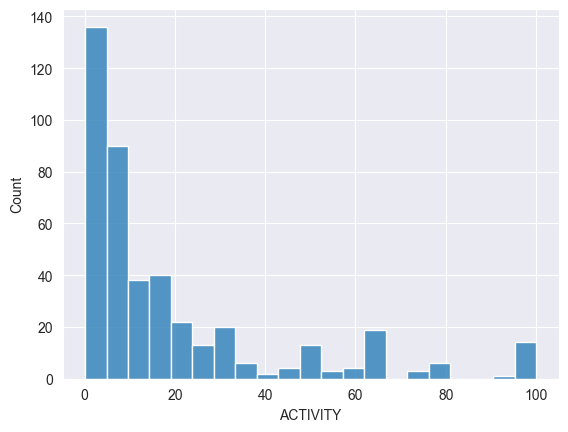

In [33]:
# histogram
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['ACTIVITY'])
plt.show()

In [35]:
# mean
print(df['ACTIVITY'].mean())

19.48333525345622


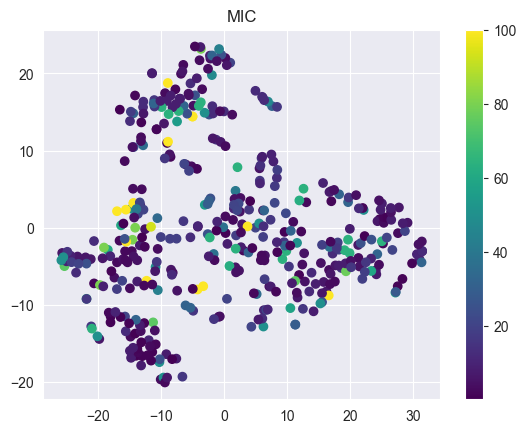

In [34]:
# tsne
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
X = df.drop(columns=['ACTIVITY'])
y = df['ACTIVITY']

tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(X)

plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=y, cmap='viridis')
plt.colorbar()
plt.title('MIC')
plt.show()